<a href="https://colab.research.google.com/github/BelenGutierrezG/CADENADEBLOQUES2/blob/develop/Copia_de_2025%2C10%2C16_(10d2%2CVerAlternativa)_Red_LSTMReg_BTC_Price_EDCR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 9 (GCB): Modelos (LSTM Regressor) de analítica de datos para la toma de decisiones de inversión en criptomonedas Bitcoin**


# **Librerías comunes:**

In [ ]:
# NumPy
import numpy as np
from numpy import where

# MatPlotLib
import matplotlib.pyplot as plt

from matplotlib import pyplot
from matplotlib import style
#plt.style.use('ggplot')
#plt.style.use('seaborn-darkgrid')
plt.style.use('fivethirtyeight')

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10,5
plt.rcParams['axes.facecolor'] = 'white'

# Seaborn
import seaborn as sns

import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

import pandas as pd
pd.Timestamp.today().strftime('%Y-%m-%d %H:%M:%S') # Se capta la fecha y hora actual

'2025-10-17 01:50:43'

# **Librerías especiales necesarias:**

In [ ]:
import statsmodels.api as sm
import datetime as dt

In [ ]:
#!pip install yfinance

In [ ]:
import yfinance as yf
yf

<module 'yfinance' from '/usr/local/lib/python3.12/dist-packages/yfinance/__init__.py'>

 * El comando yfinance nos permite a los usuarios descargar datos históricos de precios, datos de mercado en tiempo real, información financiera de empresas y mucho más.

## **Carga de Data:**

In [ ]:
ticker = 'BTC-USD'
start_date = '2014-09-17'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
# end_date = "2024-05-08"

In [ ]:
print(ticker)
print(start_date)
print(end_date)

BTC-USD
2014-09-17
2025-10-17


* En este código establece una fecha de inicio el 3 de enero de 2009 y luego utiliza la función pd.Timestamp.today() para obtener la fecha actual, que se almacena en la variable end_date con formato de cadena 'YYYY-MM-DD'. El propósito es definir un rango de fechas para descargar datos financieros desde start_date hasta la fecha actual.

In [ ]:
# Recupere los datos de precios de Bitcoin de Yahoo Finance
bitcoin_data = yf.download( ticker, start=start_date, end=end_date)
bitcoin_data

/tmp/ipython-input-3856535493.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bitcoin_data = yf.download( ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2025-10-11,110807.882812,113429.726562,109760.562500,113236.429688,110236934340
2025-10-12,115169.765625,115805.062500,109715.539062,110811.515625,93710414091


In [ ]:
bitcoin_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4047 entries, 2014-09-17 to 2025-10-15
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   4047 non-null   float64
 1   (High, BTC-USD)    4047 non-null   float64
 2   (Low, BTC-USD)     4047 non-null   float64
 3   (Open, BTC-USD)    4047 non-null   float64
 4   (Volume, BTC-USD)  4047 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 189.7 KB


In [ ]:
bitcoin_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

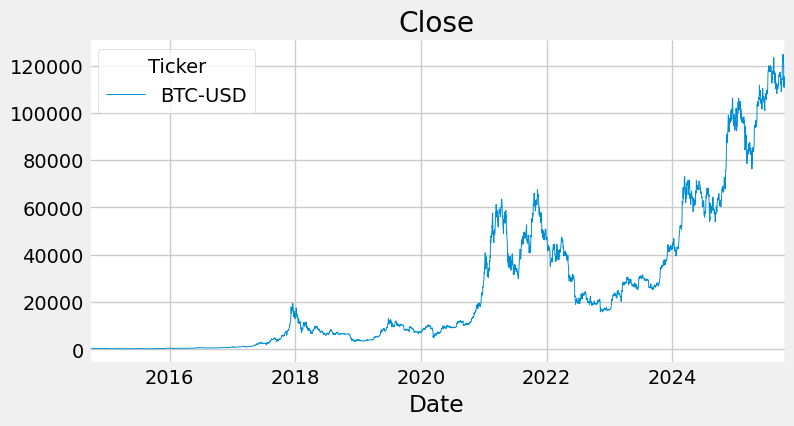

In [ ]:
from matplotlib import pyplot as plt
bitcoin_data['Close'].plot(kind='line', figsize=(8, 4), title='Close', linewidth=0.7)
plt.gca().spines[['top', 'right']].set_visible(False)

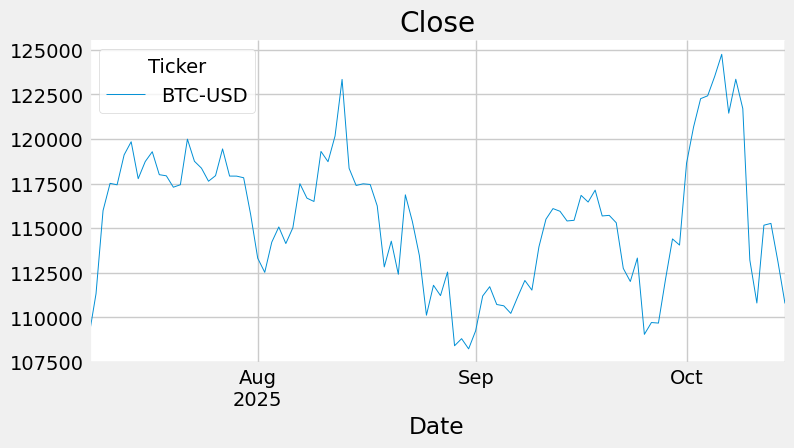

In [ ]:
from matplotlib import pyplot as plt
bitcoin_data['Close'].tail(100).plot(kind='line', figsize=(8, 4), title='Close', linewidth=0.7)
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
bitcoin_price = bitcoin_data['Close']
print(bitcoin_price)

Ticker            BTC-USD
Date                     
2014-09-17     457.334015
2014-09-18     424.440002
2014-09-19     394.795990
2014-09-20     408.903992
2014-09-21     398.821014
...                   ...
2025-10-11  110807.882812
2025-10-12  115169.765625
2025-10-13  115271.078125
2025-10-14  113118.664062
2025-10-15  110783.164062

[4047 rows x 1 columns]


*  En este código se utiliza la variable bitcoin_data para acceder a la columna 'Close' y almacena esa columna en la variable bitcoin_price.

## **Transformacion de Date de formato de Fecha a formato de Numeros Enteros:**

In [ ]:
genesis_date = dt.datetime(2014, 9, 16)
genesis_date

datetime.datetime(2014, 9, 16, 0, 0)

In [ ]:
bitcoin_price.index

DatetimeIndex(['2014-09-17', '2014-09-18', '2014-09-19', '2014-09-20',
               '2014-09-21', '2014-09-22', '2014-09-23', '2014-09-24',
               '2014-09-25', '2014-09-26',
               ...
               '2025-10-06', '2025-10-07', '2025-10-08', '2025-10-09',
               '2025-10-10', '2025-10-11', '2025-10-12', '2025-10-13',
               '2025-10-14', '2025-10-15'],
              dtype='datetime64[ns]', name='Date', length=4047, freq=None)

In [ ]:
days_since_genesis = (bitcoin_price.index - genesis_date).days
days_since_genesis

Index([   1,    2,    3,    4,    5,    6,    7,    8,    9,   10,
       ...
       4038, 4039, 4040, 4041, 4042, 4043, 4044, 4045, 4046, 4047],
      dtype='int64', name='Date', length=4047)

* En este código se  calcula la cantidad de días transcurridos desde la fecha de génesis de Bitcoin hasta la fecha de cada valor en la serie bitcoin_price.

In [ ]:
bitcoin_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [ ]:
# Construcción del dataframe
df = pd.DataFrame({'price': bitcoin_data[('Close', 'BTC-USD')]
                   })
df.sample(3)

,price
Date,
2023-06-20,28327.488281
2017-08-25,4371.600098
2018-04-05,6811.470215


<Axes: xlabel='Date'>

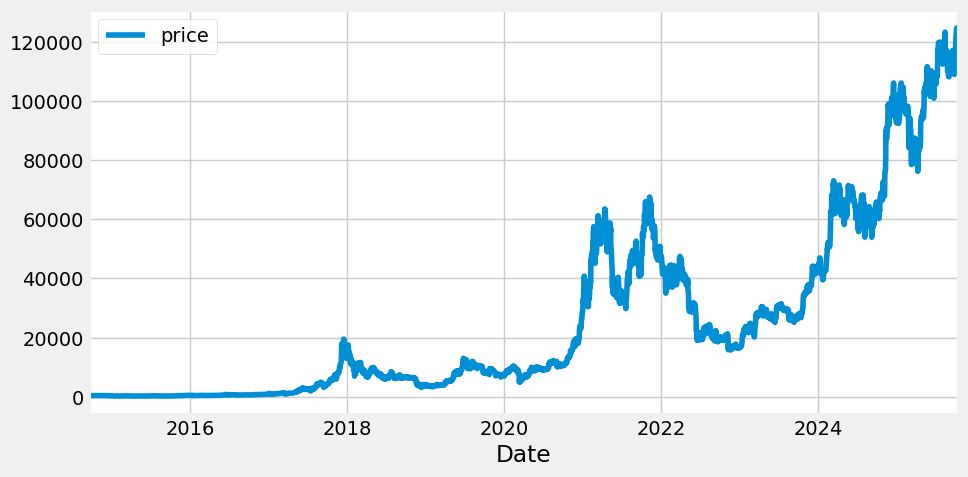

In [ ]:
df.plot()

In [ ]:
df.index = days_since_genesis
df

,price
Date,
1,457.334015
2,424.440002
3,394.795990
4,408.903992
5,398.821014
...,...
4043,110807.882812
4044,115169.765625
4045,115271.078125


## **Analisis Grafico de la Serie de Precios del Bitcoin:**

In [ ]:
Time_Series05 = df
print(type(Time_Series05))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
Time_Series05B = Time_Series05.price.rolling(window = 100, center=True).mean()
Time_Series05B.dropna(how='any', inplace=True)
Time_Series05B

,price
Date,
51,366.468409
52,365.174309
53,364.088539
54,363.312970
55,362.350630
...,...
3994,115299.514609
3995,115370.868906
3996,115441.267891


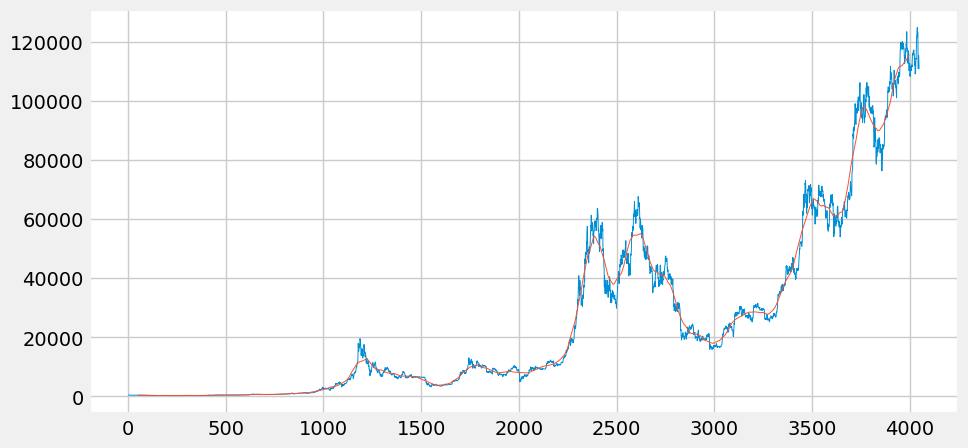

In [ ]:
plt.plot(Time_Series05, linewidth=0.7)
plt.plot(Time_Series05B, linewidth=0.7)


* El código proporcionado calcula la media móvil de 100 días de los precios de Bitcoin en la serie Time_Series05.price. La media móvil se utiliza para suavizar los datos de precios ruidosos y proporcionar una tendencia general de los precios de Bitcoin.
* El resultado se almacena en la variable Time_Series05B. Luego, se elimina cualquier valor nulo que pueda haberse creado en el cálculo de la media móvil utilizando el método .dropna(how='any', inplace=True). La salida es una serie de Pandas que contiene la media móvil de 100 días de los precios de Bitcoin.

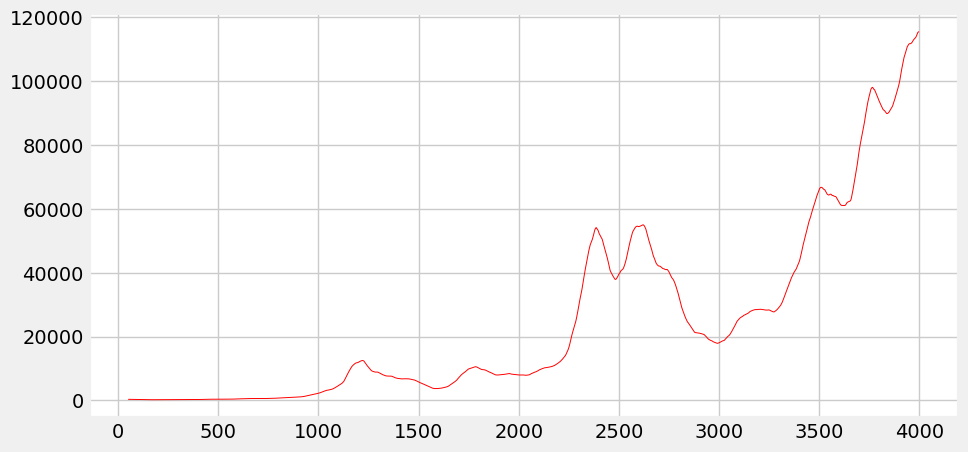

In [ ]:
plt.plot(Time_Series05B, color="red", linewidth=0.7)

In [ ]:
Time_Series05C = df
Time_Series05C["price"] = np.log(Time_Series05C["price"])
Time_Series05C

,price
Date,
1,6.125414
2,6.050771
3,5.978369
4,6.013480
5,5.988513
...,...
4043,11.615553
4044,11.654163
4045,11.655042


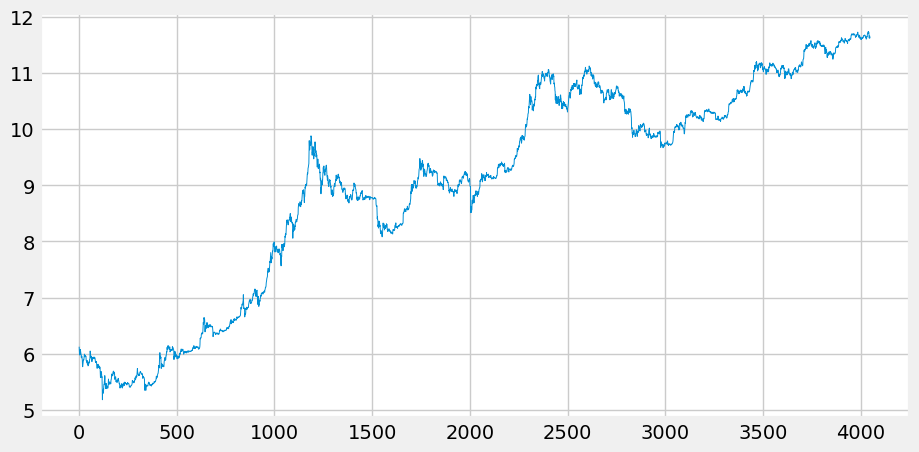

In [ ]:
plt.plot(Time_Series05C, linewidth=0.7)

In [ ]:
Time_Series05C2 = Time_Series05C.price.rolling(window = 100, center=True).mean()
Time_Series05C2.dropna(how='any', inplace=True)
Time_Series05C2

,price
Date,
51,5.900817
52,5.897491
53,5.894536
54,5.892349
55,5.889666
...,...
3994,11.654681
3995,11.655321
3996,11.655951


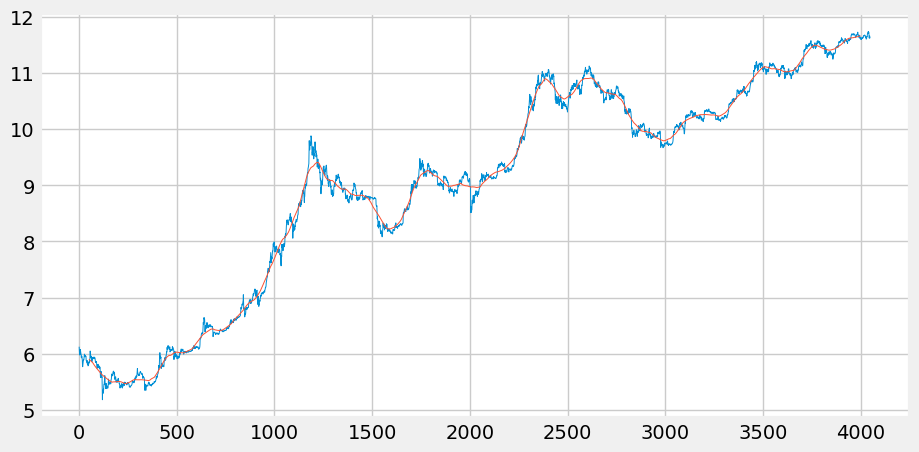

In [ ]:
plt.plot(Time_Series05C, linewidth=0.7)
plt.plot(Time_Series05C2, linewidth=0.7)

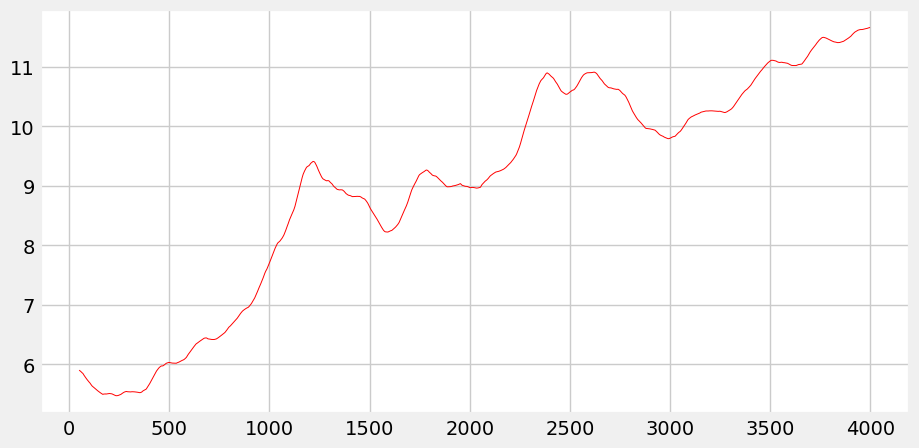

In [ ]:
plt.plot(Time_Series05C2, color="red", linewidth=0.7)

## **MODELO: Red Neuronal LSTM**

### **Carga de Libreria para Desarrollar Redes Neuronales LSTM de Keras:**

In [ ]:
import math
import pandas_datareader as web
from pandas_datareader import data as pdr

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

In [ ]:
Sequential

keras.src.models.sequential.Sequential

In [ ]:
Dense

keras.src.layers.core.dense.Dense

In [ ]:
LSTM

keras.src.layers.rnn.lstm.LSTM

In [ ]:
import tensorflow as tf
tf

<module 'tensorflow' from '/usr/local/lib/python3.12/dist-packages/tensorflow/__init__.py'>

In [ ]:
from sklearn.preprocessing import MinMaxScaler
MinMaxScaler

sklearn.preprocessing._data.MinMaxScaler

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaler

MinMaxScaler()

*  Esta línea de código se utilizará para normalizar los datos en un rango entre 0 y 1, lo que es importante para muchos algoritmos de aprendizaje profundo y finalmente la salida del código es el objeto MinMaxScaler almacenado en la variable scaler.

In [ ]:
df2 = scaler.fit_transform(np.array(Time_Series05C2).reshape(-1,1))
df2

array([[0.06950588],
       [0.06896813],
       [0.06849048],
       ...,
       [0.99990683],
       [0.99996335],
       [1.        ]])

In [ ]:
print(len(df2))
print(type(df2))

3948
<class 'numpy.ndarray'>


In [ ]:
test_size = round(len(df2) * 0.20)
test_size

790

In [ ]:
training_size = len(df2) - test_size
training_size

3158

PARTICIONAR LA DATA EN: TRAINING y PRUEBA

In [ ]:
train_data = df2[0:training_size,:]
len(train_data)

3158

In [ ]:
train_data

array([[0.06950588],
       [0.06896813],
       [0.06849048],
       ...,
       [0.77388367],
       [0.77394144],
       [0.77388226]])

In [ ]:
test_data = df2[training_size:len(df2),:1]
len(test_data)

790

In [ ]:
test_data[:6]

array([[0.77378752],
       [0.77373243],
       [0.77369488],
       [0.77365455],
       [0.77359966],
       [0.77355377]])

In [ ]:
#test_data

## **Convertir una matriz de valores en una matriz de conjunto de datos**

In [ ]:
def create_dataset(dataset, time_step = 100):
	dataX, dataY = [], []
	for i in range(len(dataset) - time_step):
		#print("i: ", i)
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return np.array(dataX), np.array(dataY)

In [ ]:
time_step = 100

In [ ]:
X_train, y_train = create_dataset(train_data, time_step)

In [ ]:
X_train

array([[0.06950588, 0.06896813, 0.06849048, ..., 0.01158391, 0.01113215,
        0.01074802],
       [0.06896813, 0.06849048, 0.06813689, ..., 0.01113215, 0.01074802,
        0.01037769],
       [0.06849048, 0.06813689, 0.0677031 , ..., 0.01074802, 0.01037769,
        0.01000618],
       ...,
       [0.75741362, 0.7577117 , 0.75795634, ..., 0.77382942, 0.7738156 ,
        0.77384353],
       [0.7577117 , 0.75795634, 0.75826364, ..., 0.7738156 , 0.77384353,
        0.77388367],
       [0.75795634, 0.75826364, 0.75851315, ..., 0.77384353, 0.77388367,
        0.77394144]])

In [ ]:
len(X_train)

3058

In [ ]:
X_test, ytest = create_dataset(test_data, time_step)

In [ ]:
X_test

array([[0.77378752, 0.77373243, 0.77369488, ..., 0.77892682, 0.77936855,
        0.77993258],
       [0.77373243, 0.77369488, 0.77365455, ..., 0.77936855, 0.77993258,
        0.78052069],
       [0.77369488, 0.77365455, 0.77359966, ..., 0.77993258, 0.78052069,
        0.78109618],
       ...,
       [0.97352157, 0.97393941, 0.9743774 , ..., 0.99968454, 0.99970155,
        0.99980495],
       [0.97393941, 0.9743774 , 0.97483023, ..., 0.99970155, 0.99980495,
        0.99990683],
       [0.9743774 , 0.97483023, 0.97531373, ..., 0.99980495, 0.99990683,
        0.99996335]])

In [ ]:
len(ytest)

690

## **Preparación de datos:**

### **Nuestra capa LSTM-RNN  necesita los datos en una matriz 3D.**

Tenemos que preparar nuestros datos para convertirlos en una matriz 3D y podamos usarlos con una capa LSTM

In [ ]:
X_train.shape[0]

3058

In [ ]:
X_train.shape[1]

100

In [ ]:
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)

In [ ]:
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

* En este punto se está cambiando la forma de las matrices de entrada X_train y X_test para que sean compatibles con el formato de entrada requerido para la red neuronal LSTM.

* La nueva forma de las matrices de entrada es (n_samples, time_step, n_features), donde n_samples es el número de muestras de entrenamiento/prueba, time_step es la longitud de la secuencia de entrada y n_features es el número de características o variables en la secuencia de entrada (en este caso, 1, ya que solo se utiliza el precio de Bitcoin como variable).

* La función reshape() se utiliza para cambiar la forma de las matrices de entrada, y se proporciona la nueva forma de la matriz como argumento.

## **Añadir secuencialmente capas a nuestra red neuronal recurrente (RNN):**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
LSTM

keras.src.layers.rnn.lstm.LSTM

In [ ]:
Sequential

keras.src.models.sequential.Sequential

In [ ]:
Dense

keras.src.layers.core.dense.Dense

In [ ]:
model = Sequential()
model

<Sequential name=sequential, built=False>

* En este cod se está agregando una capa de la red neuronal LSTM al modelo.

* Esta capa tendrá 100 unidades de memoria o neuronas, se utiliza la función de activación 'relu' para la activación de las neuronas, y return_sequences=True indica que se deben devolver las secuencias completas de salida de cada paso de tiempo en lugar de solo la salida final.

In [ ]:
model.add(LSTM(100, activation='relu', return_sequences=True, input_shape=(100,1)))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        40,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,800 (159.38 KB)

 Trainable params: 40,800 (159.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(LSTM(100, activation='relu', return_sequences=True,))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 100)       │        80,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,200 (473.44 KB)

 Trainable params: 121,200 (473.44 KB)

 Non-trainable params: 0 (0.00 B)

* El resultado indica que el modelo secuencial tiene dos capas LSTM. La primera capa tiene una salida con forma (None, 100, 100), lo que significa que tiene 100 neuronas y espera una entrada de secuencia de longitud 100. La cantidad de parámetros de esta capa es de 40,800. La segunda capa también tiene 100 neuronas y espera una entrada de secuencia de longitud 100. La cantidad de parámetros de esta capa es de 80,400. En total, el modelo tiene 121,200 parámetros, que son entrenables.

In [ ]:
model.add(LSTM(100, activation='relu'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,600 (787.50 KB)

 Trainable params: 201,600 (787.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(Dense(1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 100)       │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 100)       │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,701 (787.89 KB)

 Trainable params: 201,701 (787.89 KB)

 Non-trainable params: 0 (0.00 B)

* La primera capa LSTM tiene una entrada de forma (None, 100, 1) y produce una salida de forma (None, 100). Tiene 40800 parámetros entrenables.

* La segunda capa  también tiene una entrada de forma (None, 100, 1) y produce una salida de forma (None, 100). Tiene 80400 parámetros entrenables.

* La tercera capa LSTM tiene una entrada de forma (None, 100) y produce una salida de forma (None, 1). Tiene 80400 parámetros entrenables.

* La última capa densa tiene una entrada de forma (None, 100) y produce una salida de forma (None, 1). Tiene 101 parámetros entrenables.

* El total de parámetros entrenables del modelo es de 201,701.

In [ ]:
# from IPython.display import SVG
# from keras.utils.vis_utils import model_to_dot

# SVG(model_to_dot(
#    model,
#    show_shapes=True,
#   show_dtype=False,
#    show_layer_names=True,
#    rankdir="TB",
#    expand_nested=False,
#    dpi=70,
#    subgraph=False).create(prog='dot', format='svg'))

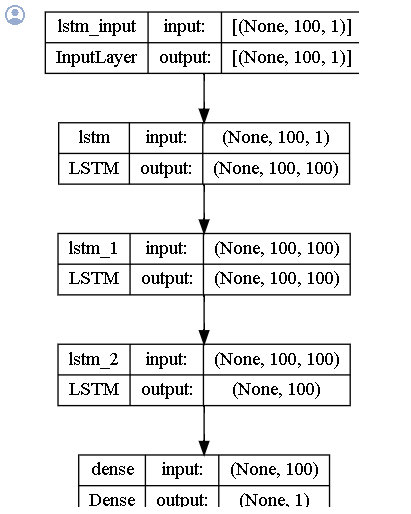

* El grafico contiene información sobre la forma de entrada y salida de cada capa, el número de parámetros en cada capa y el nombre de cada capa en el modelo. Esta información nos sirve para visualizar la estructura de la red neuronal de manera más intuitiva.

## **Compilar nuestro modelo:**

In [ ]:
model.compile(loss='mean_squared_error', optimizer='adam')

* Este código compila el modelo especificando la función de pérdida y el optimizador que se utilizarán durante el entrenamiento. En este caso, se está utilizando el error cuadrático medio (mean squared error) como función de pérdida y el algoritmo de optimización "Adam". El objetivo del compilador es preparar el modelo para el entrenamiento.

## **Proceso de FITTING (AJUSTE) del MODELO:**

In [ ]:
X_train.shape

(3058, 100, 1)

In [ ]:
X_test.shape

(690, 100, 1)

In [ ]:
len(y_train)

3058

In [ ]:
%%time
model.fit(
    X_train,
    y_train,
    validation_data = (X_test, ytest),
    epochs=20,
    batch_size=64,
    verbose=1)

Epoch 1/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - loss: 0.1312 - val_loss: 3.5173e-04
Epoch 2/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 1.4481e-04 - val_loss: 1.6187e-04
Epoch 3/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 8.1407e-05 - val_loss: 2.3212e-04
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 8.6301e-05 - val_loss: 7.8420e-05
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.4715e-05 - val_loss: 6.4429e-05
Epoch 6/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 7.7413e-05 - val_loss: 5.3291e-05
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 6.8515e-05 - val_loss: 5.2015e-05
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 7.0304e-05 - val_loss: 3.5398e-05
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 5.7830e-05 - val_loss: 2.6900e-04
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 6.3639e-05 - val_loss: 3.0034e-04
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 5.7379e-05 

## **PREDICCION CON X_TRAIN:**

In [ ]:
y_train.shape

(3058,)

In [ ]:
%%time
train_predict = model.predict(X_train)
train_predict

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
CPU times: user 2.51 s, sys: 64.4 ms, total: 2.58 s
Wall time: 2.58 s


array([[0.01747085],
       [0.01681387],
       [0.01616278],
       ...,
       [0.77711767],
       [0.77713746],
       [0.7771589 ]], dtype=float32)

In [ ]:
len(train_predict)

3058

* Este código realiza la predicción de los valores de entrenamiento X_train utilizando el modelo model. La salida train_predict contiene las predicciones correspondientes a cada muestra en X_train.

In [ ]:
##Transformar para volver a la forma original
train_predict_v2 = scaler.inverse_transform(train_predict)

In [ ]:
train_predict_v2

array([[ 5.5789466],
       [ 5.574883 ],
       [ 5.5708556],
       ...,
       [10.277856 ],
       [10.277978 ],
       [10.2781105]], dtype=float32)

* El resultado es una matriz numpy que contiene las predicciones del modelo entrenado para el conjunto de entrenamiento X_train.

* Cada valor en la matriz es una predicción numérica continua correspondiente en el conjunto de entrenamiento. La forma de la matriz es (n, 1) donde n es el número de observaciones en el conjunto de entrenamiento.

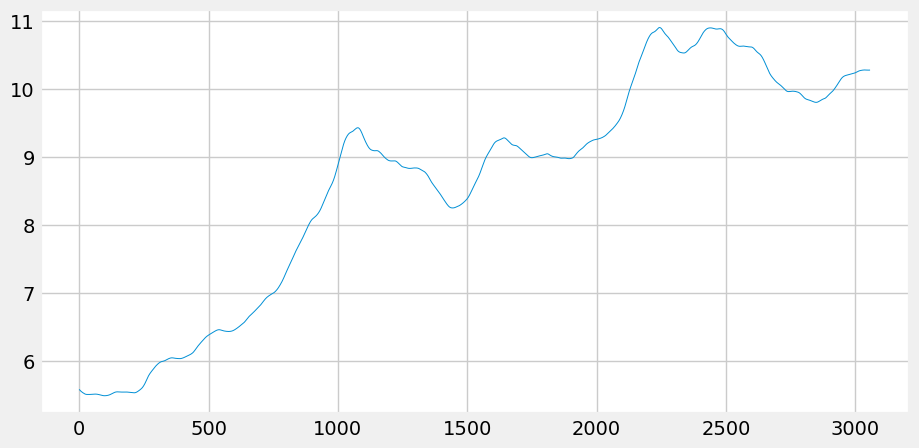

In [ ]:
plt.plot(train_predict_v2, linewidth=0.7)

In [ ]:
train_predict_v3 = pd.DataFrame(train_predict_v2, columns = ['Predicción'])
train_predict_v3

,Predicción
0,5.578947
1,5.574883
2,5.570856
3,5.566881
4,5.562977
...,...
3053,10.277643
3054,10.277743
3055,10.277856
3056,10.277978


In [ ]:
train_predict_v3.index = train_predict_v3.index + 100 + 1 + 50
train_predict_v3

,Predicción
151,5.578947
152,5.574883
153,5.570856
154,5.566881
155,5.562977
...,...
3204,10.277643
3205,10.277743
3206,10.277856
3207,10.277978


In [ ]:
Time_Series05C2

,price
Date,
51,5.900817
52,5.897491
53,5.894536
54,5.892349
55,5.889666
...,...
3994,11.654681
3995,11.655321
3996,11.655951


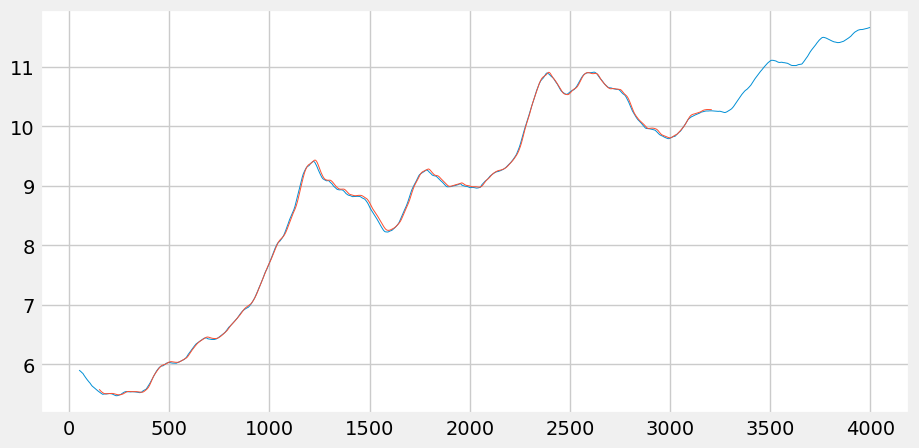

In [ ]:
plt.plot(Time_Series05C2, linewidth=0.7)
plt.plot(train_predict_v3, linewidth=0.7)

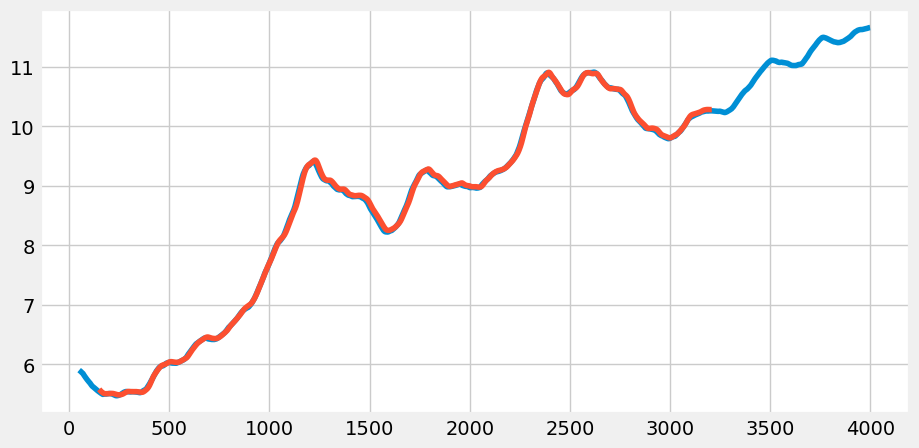

In [ ]:
plt.plot(Time_Series05C2)
plt.plot(train_predict_v3)

## **PREDICCION CON X_TEST:**

In [ ]:
test_predict = model.predict(X_test)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [ ]:
test_predict[:8]

array([[0.78191215],
       [0.78237385],
       [0.7828434 ],
       [0.7833245 ],
       [0.7838207 ],
       [0.7843345 ],
       [0.784868  ],
       [0.7854231 ]], dtype=float32)

* model.predict(X_test) aplica la red neuronal LSTM entrenada al conjunto de datos de prueba X_test para hacer predicciones de la serie de tiempo y las almacena en la variable test_predict

In [ ]:
## conversión a la forma original

test_predict_v2 =scaler.inverse_transform(test_predict)

In [ ]:
test_predict_v2[:8]

array([[10.307513],
       [10.310369],
       [10.313273],
       [10.316249],
       [10.319319],
       [10.322496],
       [10.325796],
       [10.32923 ]], dtype=float32)

In [ ]:
test_predict_v3 = pd.DataFrame(test_predict_v2, columns = ['Predicción'])

In [ ]:
len(test_predict_v3)

690

In [ ]:
test_predict_v3

,Predicción
0,10.307513
1,10.310369
2,10.313273
3,10.316249
4,10.319319
...,...
685,14.299109
686,14.340915
687,14.382673
688,14.424438


* En este código se realizó una predicción de precios de cierre de un activo utilizando una red neuronal recurrente LSTM.

* Se utilizó un conjunto de datos históricos para entrenar el modelo y luego se evaluó su rendimiento utilizando un conjunto de datos de prueba. El modelo se configuró con una arquitectura LSTM de varias capas y se utilizó la función de pérdida de error cuadrático medio (MSE) para optimizar los parámetros de la red.

*Finalmente, se realizaron predicciones para los datos de entrenamiento y prueba, y los resultados se invirtieron a su escala original para su interpretación.

In [ ]:
print(len(X_test))
print(type(X_test))
#500

690
<class 'numpy.ndarray'>


In [ ]:
inicio_indexacion_testeo = len(df) + 1 - 100 - 685 + 50 + 100 - 73
inicio_indexacion_testeo

3340

In [ ]:
test_predict_v3.index = test_predict_v3.index + inicio_indexacion_testeo # 2532 + 1  + 100

In [ ]:
test_predict_v3.index = test_predict_v3.index - 154

3186

In [ ]:
test_predict_v3

,Predicción
3340,10.307513
3341,10.310369
3342,10.313273
3343,10.316249
3344,10.319319
...,...
4025,14.299109
4026,14.340915
4027,14.382673
4028,14.424438


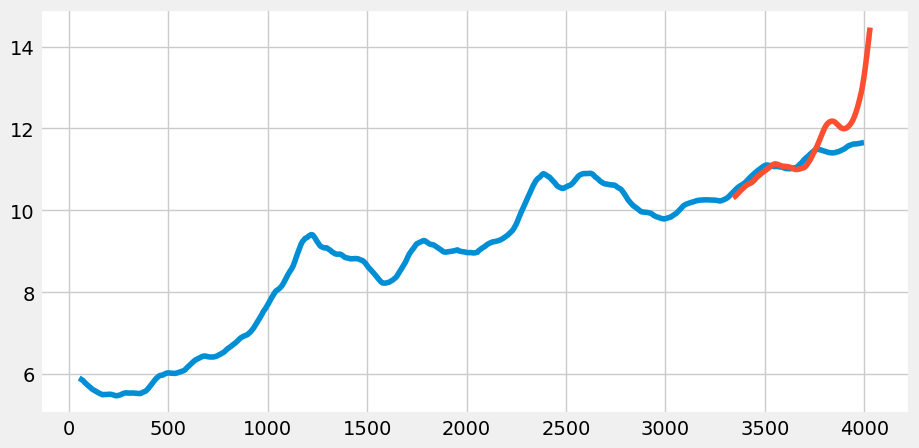

In [ ]:
plt.plot(Time_Series05C2)
plt.plot(test_predict_v3)

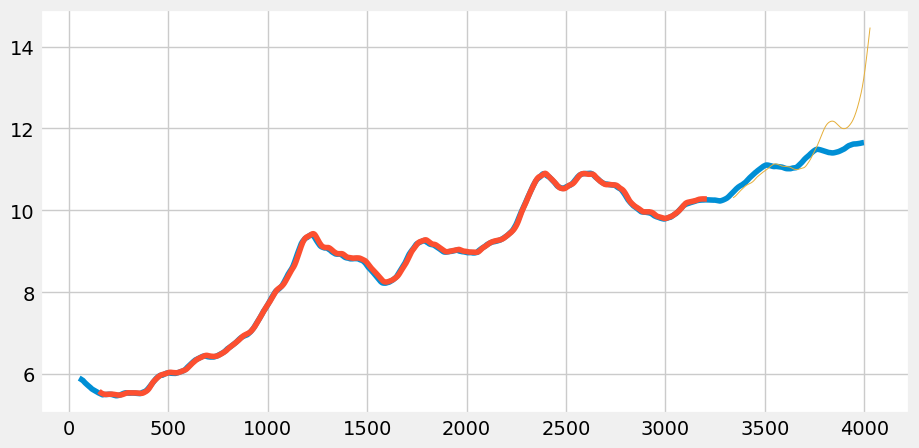

In [ ]:
plt.plot(Time_Series05C2)
plt.plot(train_predict_v3)
plt.plot(test_predict_v3, linewidth=0.7)

* **A diferencia del gráfico anterior este código traza tres líneas en un gráfico:**

* La primera línea representa los datos de la serie de tiempo original, Time_Series05C2.

* La segunda línea representa los valores de predicción de entrenamiento de la red neuronal, train_predict_v3.

* La tercera línea representa los valores de predicción de prueba de la red neuronal, test_predict_v3.

* Finalmente se puede concluir que la predicción del modelo es buena, ya que el modelo es capaz de ajustarse bien a los datos de entrenamiento (train) y también es capaz de generalizar bien en datos en test.

In [ ]:
Time_Series05C2

,price
Date,
51,5.900817
52,5.897491
53,5.894536
54,5.892349
55,5.889666
...,...
3994,11.654681
3995,11.655321
3996,11.655951


# **GENERAR PREDICCIONES ADICIONALES A FUTURO:**

In [ ]:
Time_Series06MA = pd.DataFrame(Time_Series05C2, columns = ['price'])

In [ ]:
size = len(Time_Series06MA)
size

3948

In [ ]:
%%time
for i in range(70):
  print("Iteración: ", i+1)

  # Seccion scaler.fit_transform, de ajuste del escalador obligatorio
  df2_temporal = scaler.fit_transform(np.array(Time_Series06MA).reshape(-1,1))
  print("CUMPLIDO: Seccion scaler.fit_transform, de ajuste del escalado")
  #print(type(df2_temporal))
  #print(len(df2_temporal))
  #print(df2_temporal)

  inicial = 1 + (i)
  print("inicial:", inicial)
  final = size + (i)
  print("final:", final)

  # Seccion tomar dato de la ventana que va de posicion incial a final
  experiment_array_temp = df2_temporal[inicial-1:final, : ]
  print("CUMPLIDO: Seccion tomar dato de la ventana que va de posicion incial a final")
  #print(type(experiment_array_temp))
  #print(len(experiment_array_temp))
  #print(experiment_array_temp)

  # Seccion creacion de estructura Matriz X y columna y
  experiment_array_v2_temp, y_experiment_array_v2_temp = create_dataset(
      experiment_array_temp,
      time_step)
  print("CUMPLIDO: Seccion creacion de estructura Matriz X y columna y")
  #print(type(experiment_array_v2_temp))
  #print(experiment_array_v2_temp.shape)
  #print(experiment_array_v2_temp)

  # Seccion que lleva la Matriz X a una matriz 3D
  experiment_array_v3_temp = experiment_array_v2_temp.reshape(
  experiment_array_v2_temp.shape[0],
  experiment_array_v2_temp.shape[1] , 1)
  print("CUMPLIDO: Seccion que lleva la Matriz X a una matriz 3D")
  #print(type(experiment_array_v3_temp))
  print(experiment_array_v3_temp.shape)
  #print(experiment_array_v3_temp)

  # Seccion que genera Array de Valores Ajustados a Model
  experimento_prediccion_temp = model.predict(experiment_array_v3_temp)
  print("CUMPLIDO: Seccion que genera Array de Valores Ajustados a Model")
  #print(type(experimento_prediccion_temp))
  print(experimento_prediccion_temp.shape)
  #print(experimento_prediccion_temp)

  experimento_prediccion_v2_temp = scaler.inverse_transform(experimento_prediccion_temp)

  experimento_prediccion_v3_temp = pd.DataFrame(experimento_prediccion_v2_temp, columns = ['price'])
  #print(experimento_prediccion_v3_temp)

  experimento_prediccion_v3_temp.index = experimento_prediccion_v3_temp.index + 101 + i + 50 + 2
  #print(experimento_prediccion_v3_temp)

  print("Indice del ultimo de experimento_prediccion_v3_temp:")
  print(101 + i + 50+2+len(experimento_prediccion_v3_temp)-1)
  print("Ultima fila de experimento_prediccion_v3_temp: ", experimento_prediccion_v3_temp.tail(1))
  print("Ultima fila de Time_Series06MA antes del CONCAT: ")
  print(Time_Series06MA.tail(1))

  Time_Series06MA = pd.concat([Time_Series06MA,experimento_prediccion_v3_temp.tail(1) ])
  print("Ultima fila de Time_Series06MA despues del CONCAT: ")
  print(Time_Series06MA.tail(1))
  print("Valor: ", experimento_prediccion_v3_temp.tail(1))

  print("************************************")


Iteración:  1
CUMPLIDO: Seccion scaler.fit_transform, de ajuste del escalado
inicial: 1
final: 3948
CUMPLIDO: Seccion tomar dato de la ventana que va de posicion incial a final
CUMPLIDO: Seccion creacion de estructura Matriz X y columna y
CUMPLIDO: Seccion que lleva la Matriz X a una matriz 3D
(3848, 100, 1)
121/121 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
CUMPLIDO: Seccion que genera Array de Valores Ajustados a Model
(3848, 1)
Indice del ultimo de experimento_prediccion_v3_temp:
4000
Ultima fila de experimento_prediccion_v3_temp:            price
4000  14.466284
Ultima fila de Time_Series06MA antes del CONCAT: 
          price
Date           
3998  11.656527
Ultima fila de Time_Series06MA despues del CONCAT: 
          price
4000  14.466284
Valor:            price
4000  14.466284
************************************
Iteración:  2
CUMPLIDO: Seccion scaler.fit_transform, de ajuste del escalado
inicial: 2
final: 3949
CUMPLIDO: Seccion tomar dato de la ventana que va de posicion incial a final


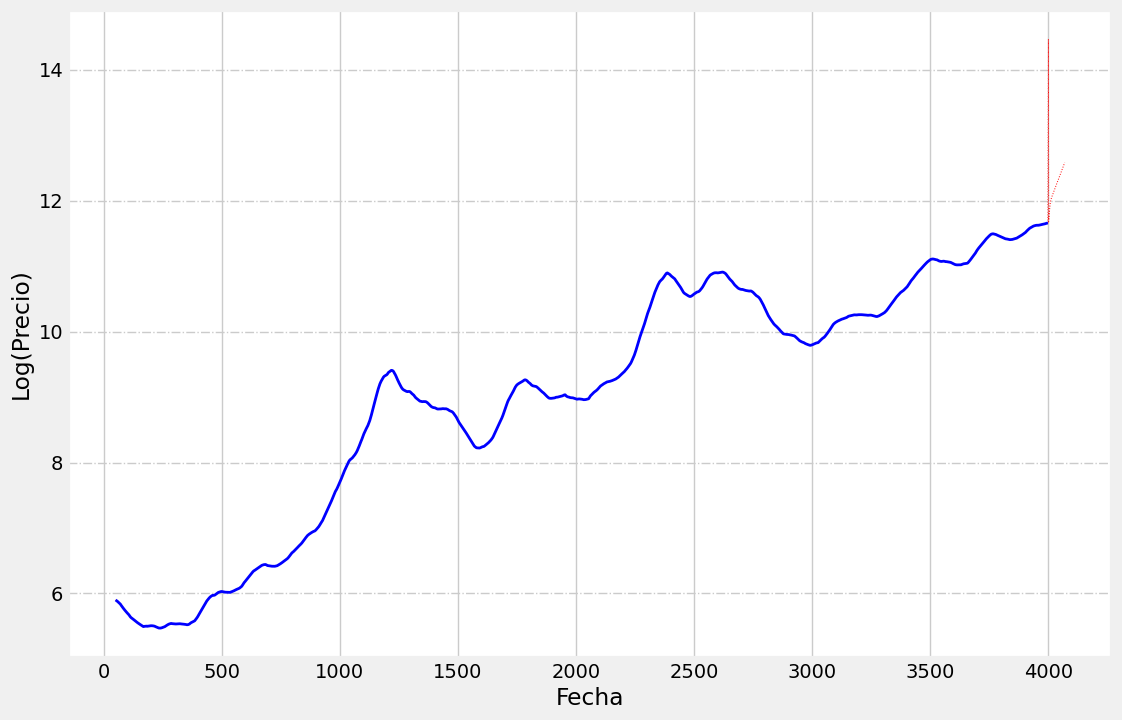

In [ ]:
plt.figure(figsize=(12,8))

plt.plot(Time_Series06MA, linestyle = "dotted", color="red", linewidth=0.7)
plt.plot(Time_Series05C2, color="blue", linewidth=2)



plt.xlabel('Fecha')
plt.ylabel('Log(Precio)')
plt.grid(axis='y', linestyle='dashdot', linewidth=1)
plt.show()

In [ ]:
Time_Series06MA_exp = np.exp(Time_Series06MA)
Time_Series06MA_exp

,price
51,365.335883
52,364.122678
53,363.048421
54,362.255252
55,361.284509
...,...
4065,279471.370753
4066,282224.988041
4067,284993.505724
4068,287772.440093


In [ ]:
Real_price = np.exp(df)

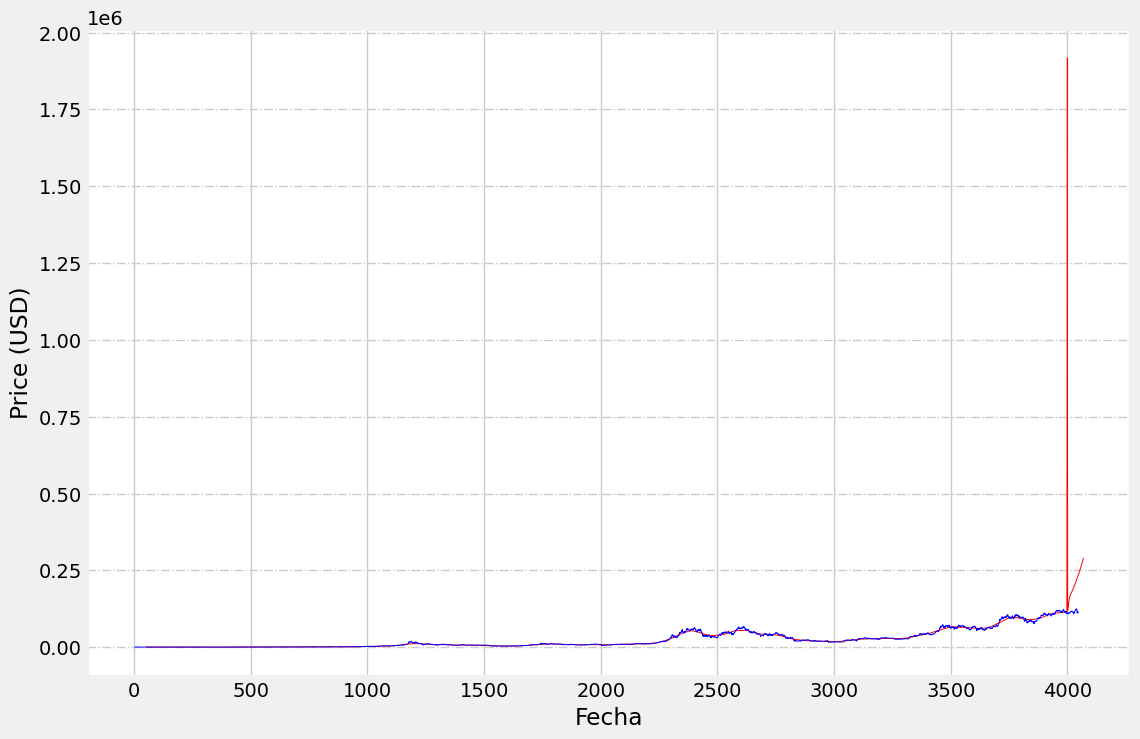

In [ ]:
plt.figure(figsize=(12,8))

plt.plot(Time_Series06MA_exp, color="red", linewidth=0.7)
plt.plot(Real_price, color="blue", linewidth=0.7 ) #linestyle = "dotted"



plt.xlabel('Fecha')
plt.ylabel('Price (USD)')
plt.grid(axis='y', linestyle='dashdot', linewidth=1)
plt.show()